# LLM Bad Smell Detection — Evaluation
Precision, Recall and F1-score per model and per smell against the human ground truth.

**Scale (both ground truth and LLM confidence):** 1 = definitely absent · 2 = probably absent · 3 = probably present · 4 = definitely present  
**Binary threshold:** mean score ≥ 3 → **present** (positive)

In [1]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('../results')
GT_CSV      = Path('../ground-truth/final-ground-truth.csv')
THRESHOLD   = 3

SMELLS = [
    'cyclic_dependency',
    'microservice_greedy',
    'nano_service',
    'no_api_gateway',
    'shared_database',
]
SMELL_LABELS = {
    'cyclic_dependency':   'Cyclic Dep.',
    'microservice_greedy': 'MS Greedy',
    'nano_service':        'Nano Service',
    'no_api_gateway':      'No API GW',
    'shared_database':     'Shared DB',
}

# Short display names for models with long directory names
MODEL_DISPLAY_NAMES = {
    'Llama-4-Maverick-17B-128E-Instruct-FP8-e81efef6': 'llama-4-maverick',
}

print('Setup done.')

Setup done.


In [2]:
# Ground Truth
# CSV has one row per system with pre-aggregated scores on a 1-4 scale.
# Columns: DIAGRAMS, PAIRS, CD, MG, NS, NAG, SD

GT_COL_MAP = {
    'CD':  'cyclic_dependency',
    'MG':  'microservice_greedy',
    'NS':  'nano_service',
    'NAG': 'no_api_gateway',
    'SD':  'shared_database',
}

gt_raw = pd.read_csv(GT_CSV)
gt_raw = gt_raw[pd.to_numeric(gt_raw['DIAGRAMS'], errors='coerce').notna()].copy()
gt_raw['sys_id'] = gt_raw['DIAGRAMS'].astype(int).astype(str)

gt_rows = []
for col, smell in GT_COL_MAP.items():
    sub = gt_raw[['sys_id', col]].copy()
    sub.columns = ['sys_id', 'score']
    sub['smell'] = smell
    gt_rows.append(sub)

gt_long = pd.concat(gt_rows, ignore_index=True)
gt_long['score'] = pd.to_numeric(gt_long['score'], errors='coerce')

gt_agg = (
    gt_long
    .groupby(['sys_id', 'smell'])['score']
    .mean()
    .reset_index()
    .rename(columns={'score': 'gt_mean'})
)
gt_agg['gt_label'] = (gt_agg['gt_mean'] >= THRESHOLD).astype(int)

print('Ground truth binary labels (1=present, 0=absent):')
print(gt_agg.pivot(index='sys_id', columns='smell', values='gt_label').to_string())

Ground truth binary labels (1=present, 0=absent):
smell   cyclic_dependency  microservice_greedy  nano_service  no_api_gateway  shared_database
sys_id                                                                                       
1                       0                    0             1               0                0
2                       0                    0             0               1                0
3                       0                    0             0               0                0
4                       0                    0             0               0                0
5                       0                    1             1               1                1
6                       0                    1             0               0                0
7                       0                    1             0               0                0
8                       0                    0             0               0                0
9         

In [3]:
# LLM Predictions
# Walk results/**/<system>/<smell>/run_*.json using rglob to handle any nesting depth.
# The model name is the immediate parent directory of the system directory.
# Average confidence across runs, then binarise.

pred_rows = []

for run_file in sorted(RESULTS_DIR.rglob('run_*.json')):
    smell_dir = run_file.parent
    if smell_dir.name not in SMELLS:
        continue
    sys_dir = smell_dir.parent
    m = re.match(r'^(\d+)', sys_dir.name)
    if not m:
        continue
    sys_id = m.group(1)
    raw_model = sys_dir.parent.name
    model_name = MODEL_DISPLAY_NAMES.get(raw_model, raw_model)

    with open(run_file) as f:
        data = json.load(f)
    confidence = data.get('confidence')
    if confidence is not None:
        pred_rows.append({
            'model':      model_name,
            'sys_id':     sys_id,
            'smell':      smell_dir.name,
            'confidence': float(confidence),
        })

pred_df = pd.DataFrame(pred_rows)

pred_agg = (
    pred_df
    .groupby(['model', 'sys_id', 'smell'])['confidence']
    .mean()
    .reset_index()
    .rename(columns={'confidence': 'pred_mean'})
)
pred_agg['pred_label'] = (pred_agg['pred_mean'] >= THRESHOLD).astype(int)

print(f"Models  : {sorted(pred_agg['model'].unique())}")
print(f"Systems : {sorted(pred_agg['sys_id'].unique())}")
print(f"Total prediction rows: {len(pred_agg)}")

Models  : ['claude-sonnet-4-6', 'gemini-2.5-pro', 'gemma-3n-E4B-it', 'gpt-5.3-codex', 'gpt-5.4', 'llama-4-maverick', 'qwen-vl-max']
Systems : ['1', '2', '3', '4', '5', '6', '7', '8', '9']
Total prediction rows: 315


In [4]:
# Merge and compute TP / FP / TN / FN

merged = pred_agg.merge(gt_agg[['sys_id', 'smell', 'gt_label']], on=['sys_id', 'smell'], how='inner')
print(f"Merged rows: {len(merged)}")

merged['TP'] = ((merged['pred_label'] == 1) & (merged['gt_label'] == 1)).astype(int)
merged['FP'] = ((merged['pred_label'] == 1) & (merged['gt_label'] == 0)).astype(int)
merged['TN'] = ((merged['pred_label'] == 0) & (merged['gt_label'] == 0)).astype(int)
merged['FN'] = ((merged['pred_label'] == 0) & (merged['gt_label'] == 1)).astype(int)

merged.head(10)

Merged rows: 315


,model,sys_id,smell,pred_mean,pred_label,gt_label,TP,FP,TN,FN
0,claude-sonnet-4-6,1,cyclic_dependency,2.0,0,0,0,0,1,0
1,claude-sonnet-4-6,1,microservice_greedy,2.0,0,0,0,0,1,0
2,claude-sonnet-4-6,1,nano_service,3.0,1,1,1,0,0,0
3,claude-sonnet-4-6,1,no_api_gateway,1.0,0,0,0,0,1,0
4,claude-sonnet-4-6,1,shared_database,2.5,0,0,0,0,1,0
5,claude-sonnet-4-6,2,cyclic_dependency,2.0,0,0,0,0,1,0
6,claude-sonnet-4-6,2,microservice_greedy,2.0,0,0,0,0,1,0
7,claude-sonnet-4-6,2,nano_service,2.0,0,0,0,0,1,0
8,claude-sonnet-4-6,2,no_api_gateway,4.0,1,1,1,0,0,0
9,claude-sonnet-4-6,2,shared_database,1.0,0,0,0,0,1,0


In [5]:
def metrics_from(group):
    tp = group['TP'].sum()
    fp = group['FP'].sum()
    tn = group['TN'].sum()
    fn = group['FN'].sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    return pd.Series({'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
                      'Precision': round(precision, 3),
                      'Recall':    round(recall, 3),
                      'F1':        round(f1, 3)})

overall   = merged.groupby('model').apply(metrics_from).reset_index()
per_smell = merged.groupby(['model', 'smell']).apply(metrics_from).reset_index()

print('=== Overall metrics per model ===')
print(overall[['model','TP','FP','TN','FN','Precision','Recall','F1']].to_string(index=False))

=== Overall metrics per model ===
            model   TP   FP   TN  FN  Precision  Recall    F1
claude-sonnet-4-6  6.0  2.0 33.0 4.0      0.750     0.6 0.667
   gemini-2.5-pro  7.0  6.0 29.0 3.0      0.538     0.7 0.609
  gemma-3n-E4B-it 10.0 35.0  0.0 0.0      0.222     1.0 0.364
    gpt-5.3-codex  8.0  2.0 33.0 2.0      0.800     0.8 0.800
          gpt-5.4  7.0  4.0 31.0 3.0      0.636     0.7 0.667
 llama-4-maverick  7.0  3.0 32.0 3.0      0.700     0.7 0.700
      qwen-vl-max  5.0  1.0 34.0 5.0      0.833     0.5 0.625


/var/folders/c6/pyqb7yqn5_13p6hy25nw4f3w0000gn/T/ipykernel_2447/1679378257.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall   = merged.groupby('model').apply(metrics_from).reset_index()
/var/folders/c6/pyqb7yqn5_13p6hy25nw4f3w0000gn/T/ipykernel_2447/1679378257.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_smell = merged.groupby(['model', 'smell']).apply(metrics_from).reset_index()


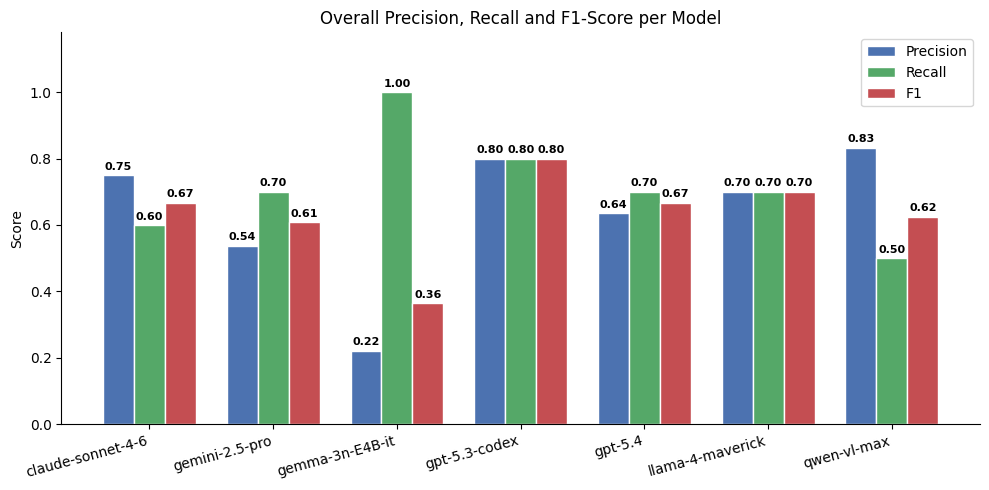

In [6]:
# Chart 1: Overall Precision / Recall / F1 per model

models = overall['model'].tolist()
x      = np.arange(len(models))
width  = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, color) in enumerate(zip(['Precision', 'Recall', 'F1'], colors)):
    bars = ax.bar(x + i * width, overall[metric], width, label=metric,
                  color=color, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Overall Precision, Recall and F1-Score per Model')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_overall.png', dpi=150)
plt.show()

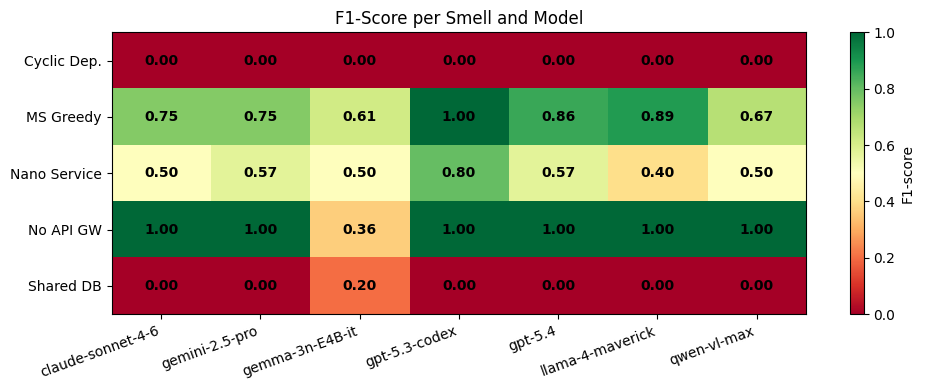

In [7]:
# Chart 2: F1-score heatmap (smell x model)

f1_pivot = per_smell.pivot(index='smell', columns='model', values='F1').reindex(SMELLS)
f1_pivot.index = [SMELL_LABELS[s] for s in f1_pivot.index]

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(f1_pivot.values.astype(float), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(f1_pivot.columns)))
ax.set_xticklabels(f1_pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(f1_pivot.index)))
ax.set_yticklabels(f1_pivot.index)

for r in range(f1_pivot.shape[0]):
    for c in range(f1_pivot.shape[1]):
        val = f1_pivot.values[r, c]
        ax.text(c, r, f'{val:.2f}' if not np.isnan(val) else 'N/A',
                ha='center', va='center', fontsize=10, fontweight='bold', color='black')

plt.colorbar(im, ax=ax, label='F1-score')
ax.set_title('F1-Score per Smell and Model')
plt.tight_layout()
plt.savefig('metrics_f1_heatmap.png', dpi=150)
plt.show()

/var/folders/c6/pyqb7yqn5_13p6hy25nw4f3w0000gn/T/ipykernel_2447/4011964412.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  smell_avg = merged.groupby('smell').apply(metrics_from).reset_index()


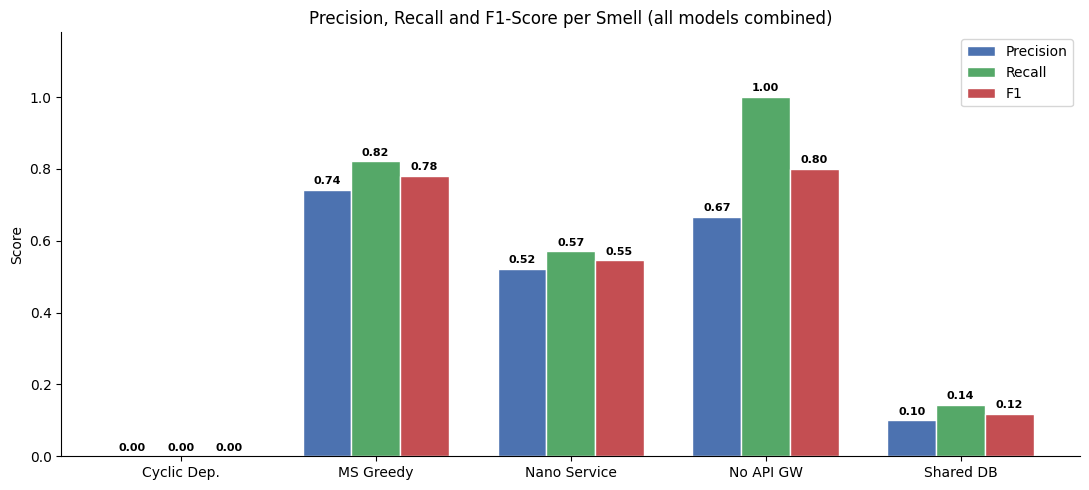

In [8]:
# Chart 3: Precision / Recall / F1 per smell (all models combined)

smell_avg = merged.groupby('smell').apply(metrics_from).reset_index()
smell_avg = smell_avg.set_index('smell').reindex(SMELLS).reset_index()
labels    = [SMELL_LABELS[s] for s in SMELLS]

x     = np.arange(len(SMELLS))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, color) in enumerate(zip(['Precision', 'Recall', 'F1'], colors)):
    bars = ax.bar(x + i * width, smell_avg[metric], width, label=metric,
                  color=color, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall and F1-Score per Smell (all models combined)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_per_smell.png', dpi=150)
plt.show()

In [9]:
print('=== Ground Truth distribution ===')
print(f'  Positive (smell present): {(gt_agg["gt_label"]==1).sum()}')
print(f'  Negative (smell absent):  {(gt_agg["gt_label"]==0).sum()}')
print()
print('=== Overall metrics per model ===')
display(overall[['model','TP','FP','TN','FN','Precision','Recall','F1']].set_index('model'))

=== Ground Truth distribution ===
  Positive (smell present): 10
  Negative (smell absent):  35

=== Overall metrics per model ===


,TP,FP,TN,FN,Precision,Recall,F1
model,,,,,,,
claude-sonnet-4-6,6.0,2.0,33.0,4.0,0.750,0.6,0.667
gemini-2.5-pro,7.0,6.0,29.0,3.0,0.538,0.7,0.609
gemma-3n-E4B-it,10.0,35.0,0.0,0.0,0.222,1.0,0.364
gpt-5.3-codex,8.0,2.0,33.0,2.0,0.800,0.8,0.800
gpt-5.4,7.0,4.0,31.0,3.0,0.636,0.7,0.667
llama-4-maverick,7.0,3.0,32.0,3.0,0.700,0.7,0.700
qwen-vl-max,5.0,1.0,34.0,5.0,0.833,0.5,0.625


In [10]:
# Structural vs Semantic analysis

STRUCTURAL = ['cyclic_dependency', 'no_api_gateway', 'shared_database']
SEMANTIC   = ['microservice_greedy', 'nano_service']

merged['category'] = merged['smell'].apply(
    lambda s: 'Structural' if s in STRUCTURAL else 'Semantic'
)

cat_per_model = merged.groupby(['model', 'category']).apply(metrics_from).reset_index()
cat_overall   = merged.groupby('category').apply(metrics_from).reset_index()

print('=== Metrics by category and model ===')
display(cat_per_model[['model', 'category', 'TP', 'FP', 'TN', 'FN', 'Precision', 'Recall', 'F1']]
        .set_index(['model', 'category']))

print('\n=== Overall metrics by category (all models combined) ===')
display(cat_overall[['category', 'TP', 'FP', 'TN', 'FN', 'Precision', 'Recall', 'F1']]
        .set_index('category'))

=== Metrics by category and model ===


/var/folders/c6/pyqb7yqn5_13p6hy25nw4f3w0000gn/T/ipykernel_2447/2893549493.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_per_model = merged.groupby(['model', 'category']).apply(metrics_from).reset_index()
/var/folders/c6/pyqb7yqn5_13p6hy25nw4f3w0000gn/T/ipykernel_2447/2893549493.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_overall   = merged.groupby('category').apply(metrics_from).reset_index()

TP    FP    TN   FN  Precision  Recall     F1
model             category                                                  
claude-sonnet-4-6 Semantic    4.0   1.0  10.0  3.0      0.800   0.571  0.667
                  Structural  2.0   1.0  23.0  1.0      0.667   0.667  0.667
gemini-2.5-pro    Semantic    5.0   3.0   8.0  2.0      0.625   0.714  0.667
                  Structural  2.0   3.0  21.0  1.0      0.400   0.667  0.500
gemma-3n-E4B-it   Semantic    7.0  11.0   0.0  0.0      0.389   1.000  0.560
                  Structural  3.0  24.0   0.0  0.0      0.111   1.000  0.200
gpt-5.3-codex     Semantic    6.0   0.0  11.0  1.0      1.000   0.857  0.923
                  Structural  2.0   2.0  22.0  1.0      0.500   0.667  0.571
gpt-5.4           Semantic    5.0   2.0   9.0  2.0      0.714   0.714  0.714
                  Structural  2.0   2.0  22.0  1.0      0.500   0.667  0.571
llama-4-maverick  Semantic    5.0   2.0   9.0  2.0      0.714   0.714  0.714
                  Structural  2.0   1.0  23.0  1.0      0.667   0.667  0.667
qwen-vl-max       Semantic    3.0   0.0  11.0  4.0      1.000   0.429  0.600
                  Structural  2.0   1.0  23.0  1.0      0.667   0.667  0.667


=== Overall metrics by category (all models combined) ===


,TP,FP,TN,FN,Precision,Recall,F1
category,,,,,,,
Semantic,35.0,19.0,58.0,14.0,0.648,0.714,0.680
Structural,15.0,34.0,134.0,6.0,0.306,0.714,0.429


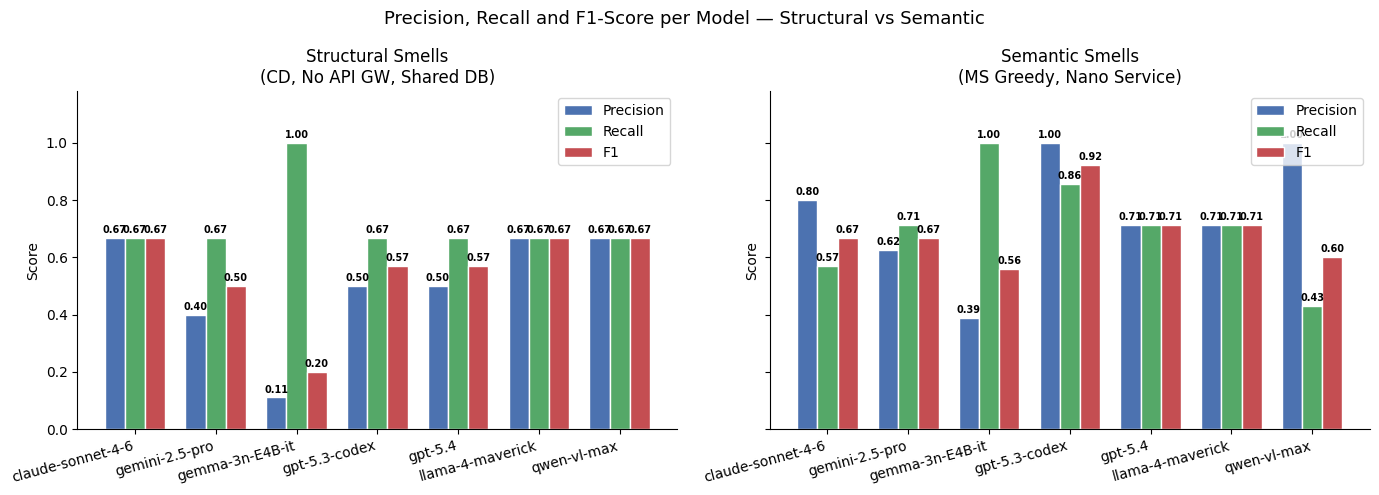

In [11]:
# Chart 4: Precision / Recall / F1 per model — Structural vs Semantic

categories = ['Structural', 'Semantic']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, category in zip(axes, categories):
    sub = cat_per_model[cat_per_model['category'] == category].copy()
    model_list = sub['model'].tolist()
    x = np.arange(len(model_list))
    width = 0.25

    for i, (metric, color) in enumerate(zip(['Precision', 'Recall', 'F1'], colors)):
        bars = ax.bar(x + i * width, sub[metric], width, label=metric,
                      color=color, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(x + width)
    ax.set_xticklabels(model_list, rotation=15, ha='right')
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score')
    ax.set_title(f'{category} Smells\n({"CD, No API GW, Shared DB" if category == "Structural" else "MS Greedy, Nano Service"})')
    ax.legend(loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Precision, Recall and F1-Score per Model — Structural vs Semantic', fontsize=13)
plt.tight_layout()
plt.savefig('metrics_structural_vs_semantic.png', dpi=150)
plt.show()

In [12]:
# False Positives and False Negatives analysis

# ── Overall FP / FN per model ─────────────────────────────────────────────────
fp_fn_overall = (
    merged.groupby('model')[['FP', 'FN', 'TP', 'TN']]
    .sum()
    .assign(Total=lambda d: d['FP'] + d['FN'] + d['TP'] + d['TN'])
    .assign(FP_rate=lambda d: (d['FP'] / d['Total']).round(3))
    .assign(FN_rate=lambda d: (d['FN'] / d['Total']).round(3))
)
print('=== Overall FP / FN per model ===')
display(fp_fn_overall)

# ── FP / FN per model × smell ─────────────────────────────────────────────────
fp_pivot = merged.groupby(['model', 'smell'])['FP'].sum().unstack(fill_value=0)
fn_pivot = merged.groupby(['model', 'smell'])['FN'].sum().unstack(fill_value=0)

print('\n=== False Positives per model x smell ===')
display(fp_pivot.rename(columns=SMELL_LABELS))

print('\n=== False Negatives per model x smell ===')
display(fn_pivot.rename(columns=SMELL_LABELS))

=== Overall FP / FN per model ===


,FP,FN,TP,TN,Total,FP_rate,FN_rate
model,,,,,,,
claude-sonnet-4-6,2,4,6,33,45,0.044,0.089
gemini-2.5-pro,6,3,7,29,45,0.133,0.067
gemma-3n-E4B-it,35,0,10,0,45,0.778,0.000
gpt-5.3-codex,2,2,8,33,45,0.044,0.044
gpt-5.4,4,3,7,31,45,0.089,0.067
llama-4-maverick,3,3,7,32,45,0.067,0.067
qwen-vl-max,1,5,5,34,45,0.022,0.111



=== False Positives per model x smell ===


smell,Cyclic Dep.,MS Greedy,Nano Service,No API GW,Shared DB
model,,,,,
claude-sonnet-4-6,1,1,0,0,0
gemini-2.5-pro,2,1,2,0,1
gemma-3n-E4B-it,9,5,6,7,8
gpt-5.3-codex,2,0,0,0,0
gpt-5.4,2,0,2,0,0
llama-4-maverick,1,1,1,0,0
qwen-vl-max,1,0,0,0,0



=== False Negatives per model x smell ===


smell,Cyclic Dep.,MS Greedy,Nano Service,No API GW,Shared DB
model,,,,,
claude-sonnet-4-6,0,1,2,0,1
gemini-2.5-pro,0,1,1,0,1
gemma-3n-E4B-it,0,0,0,0,0
gpt-5.3-codex,0,0,1,0,1
gpt-5.4,0,1,1,0,1
llama-4-maverick,0,0,2,0,1
qwen-vl-max,0,2,2,0,1


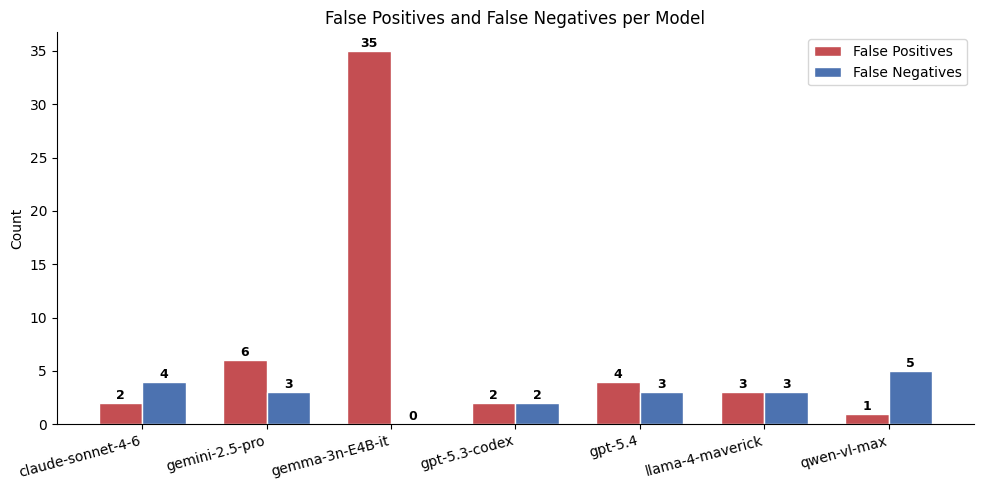

In [13]:
# Chart 5: FP vs FN per model (grouped bar)

models_list = fp_fn_overall.index.tolist()
x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_fp = ax.bar(x - width / 2, fp_fn_overall['FP'], width, label='False Positives',
                 color='#C44E52', edgecolor='white')
bars_fn = ax.bar(x + width / 2, fp_fn_overall['FN'], width, label='False Negatives',
                 color='#4C72B0', edgecolor='white')

for bar in list(bars_fp) + list(bars_fn):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
            str(int(h)), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('False Positives and False Negatives per Model')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_fp_fn_overall.png', dpi=150)
plt.show()

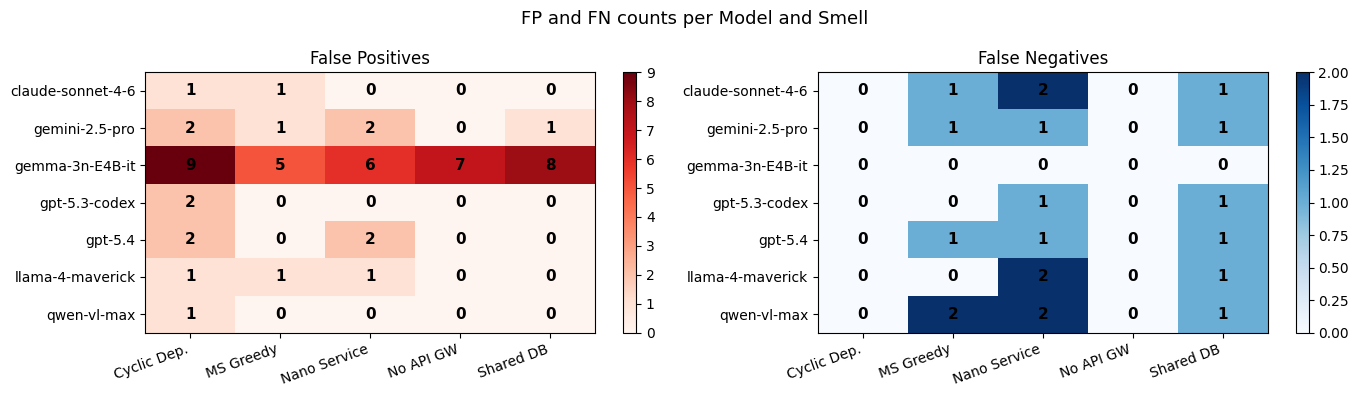

In [14]:
# Chart 6: FP and FN heatmaps per model × smell

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, pivot, title, cmap in zip(
    axes,
    [fp_pivot.reindex(columns=SMELLS), fn_pivot.reindex(columns=SMELLS)],
    ['False Positives', 'False Negatives'],
    ['Reds', 'Blues'],
):
    pivot_labeled = pivot.rename(columns=SMELL_LABELS)
    im = ax.imshow(pivot_labeled.values.astype(float), cmap=cmap, aspect='auto',
                   vmin=0, vmax=pivot_labeled.values.max())
    ax.set_xticks(range(len(pivot_labeled.columns)))
    ax.set_xticklabels(pivot_labeled.columns, rotation=20, ha='right')
    ax.set_yticks(range(len(pivot_labeled.index)))
    ax.set_yticklabels(pivot_labeled.index)
    for r in range(pivot_labeled.shape[0]):
        for c in range(pivot_labeled.shape[1]):
            ax.text(c, r, str(int(pivot_labeled.values[r, c])),
                    ha='center', va='center', fontsize=11, fontweight='bold', color='black')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

fig.suptitle('FP and FN counts per Model and Smell', fontsize=13)
plt.tight_layout()
plt.savefig('metrics_fp_fn_heatmap.png', dpi=150)
plt.show()

## Analysis by Model Category

Models are grouped into three categories:

| Category | Models |
|---|---|
| **Private general** | gemini-2.5-pro, gpt-5.4 |
| **Open source** | gemma-3n-E4B-it, llama-4-maverick, qwen-vl-max |
| **Code-specific** | claude-sonnet-4-6, gpt-5.3-codex |

In [15]:
# Model category definitions
MODEL_CATEGORY = {
    'gemini-2.5-pro':    'Private General',
    'gpt-5.4':           'Private General',
    'gemma-3n-E4B-it':   'Open Source',
    'llama-4-maverick':  'Open Source',
    'qwen-vl-max':       'Open Source',
    'claude-sonnet-4-6': 'Code-Specific',
    'gpt-5.3-codex':     'Code-Specific',
}
CATEGORY_ORDER  = ['Private General', 'Open Source', 'Code-Specific']
CATEGORY_COLORS = {'Private General': '#4C72B0', 'Open Source': '#55A868', 'Code-Specific': '#C44E52'}

merged['model_category'] = merged['model'].map(MODEL_CATEGORY)

# Metrics aggregated per category (all smells, all systems)
cat_group = merged.groupby('model_category').apply(
    metrics_from, include_groups=False
).reset_index()
cat_group = cat_group.set_index('model_category').reindex(CATEGORY_ORDER).reset_index()

print('=== Overall metrics per model category ===')
display(cat_group[['model_category', 'TP', 'FP', 'TN', 'FN', 'Precision', 'Recall', 'F1']]
        .set_index('model_category'))

# Metrics per category × smell
cat_smell = merged.groupby(['model_category', 'smell']).apply(
    metrics_from, include_groups=False
).reset_index()

print('\n=== F1 per category and smell ===')
display(
    cat_smell.pivot(index='smell', columns='model_category', values='F1')
    .reindex(SMELLS)
    .rename(index=SMELL_LABELS)
)

=== Overall metrics per model category ===


,TP,FP,TN,FN,Precision,Recall,F1
model_category,,,,,,,
Private General,14.0,10.0,60.0,6.0,0.583,0.700,0.636
Open Source,22.0,39.0,66.0,8.0,0.361,0.733,0.484
Code-Specific,14.0,4.0,66.0,6.0,0.778,0.700,0.737



=== F1 per category and smell ===


model_category,Code-Specific,Open Source,Private General
smell,,,
Cyclic Dep.,0.000,0.000,0.000
MS Greedy,0.875,0.714,0.800
Nano Service,0.667,0.476,0.571
No API GW,1.000,0.632,1.000
Shared DB,0.000,0.167,0.000


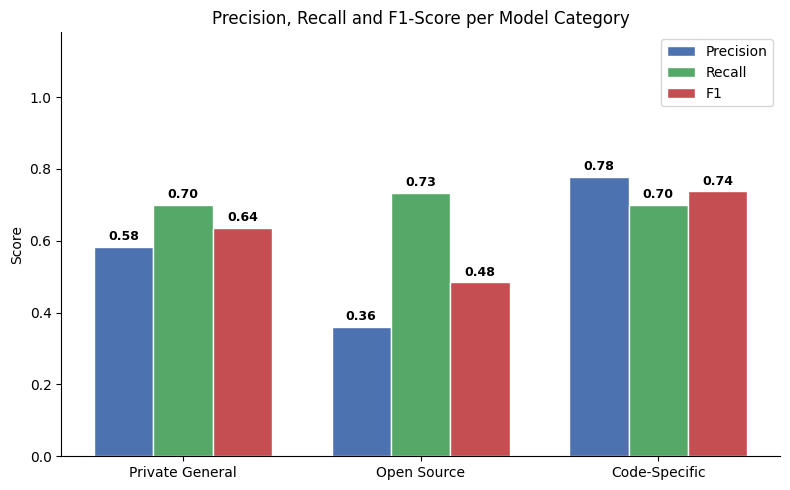

In [16]:
# Chart 7: Overall Precision / Recall / F1 per model category

x     = np.arange(len(CATEGORY_ORDER))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, (metric, color) in enumerate(zip(['Precision', 'Recall', 'F1'], ['#4C72B0', '#55A868', '#C44E52'])):
    bars = ax.bar(x + i * width, cat_group[metric], width, label=metric,
                  color=color, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(CATEGORY_ORDER)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall and F1-Score per Model Category')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_by_category.png', dpi=150)
plt.show()

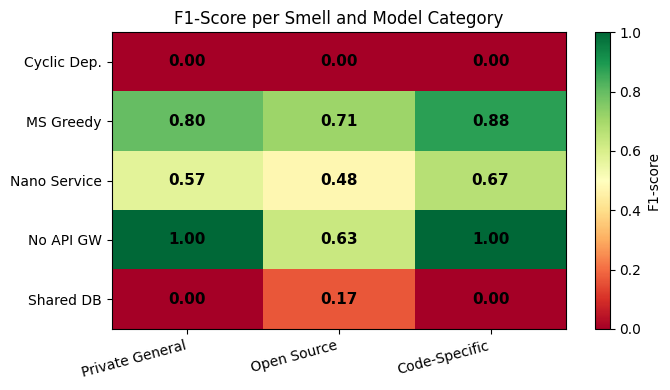

In [17]:
# Chart 8: F1-score heatmap — smell × model category

f1_cat_pivot = (
    cat_smell
    .pivot(index='smell', columns='model_category', values='F1')
    .reindex(SMELLS)[CATEGORY_ORDER]
)
f1_cat_pivot.index = [SMELL_LABELS[s] for s in f1_cat_pivot.index]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(f1_cat_pivot.values.astype(float), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(CATEGORY_ORDER)))
ax.set_xticklabels(CATEGORY_ORDER, rotation=15, ha='right')
ax.set_yticks(range(len(f1_cat_pivot.index)))
ax.set_yticklabels(f1_cat_pivot.index)

for r in range(f1_cat_pivot.shape[0]):
    for c in range(f1_cat_pivot.shape[1]):
        val = f1_cat_pivot.values[r, c]
        ax.text(c, r, f'{val:.2f}' if not np.isnan(val) else 'N/A',
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')

plt.colorbar(im, ax=ax, label='F1-score')
ax.set_title('F1-Score per Smell and Model Category')
plt.tight_layout()
plt.savefig('metrics_category_f1_heatmap.png', dpi=150)
plt.show()

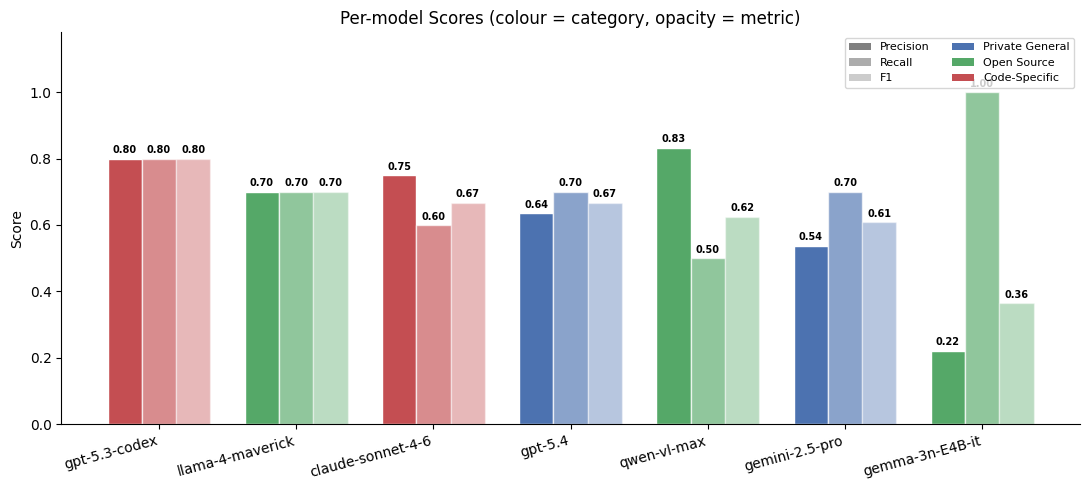

In [18]:
# Chart 9: Individual model scores, coloured by category

model_order = overall.sort_values('F1', ascending=False)['model'].tolist()
overall_cat = overall.copy()
overall_cat['category'] = overall_cat['model'].map(MODEL_CATEGORY)
overall_cat = overall_cat.set_index('model').reindex(model_order).reset_index()

bar_colors = [CATEGORY_COLORS[c] for c in overall_cat['category']]

x     = np.arange(len(model_order))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(['Precision', 'Recall', 'F1']):
    alpha = [1.0, 0.65, 0.4][i]
    bars = ax.bar(x + i * width, overall_cat[metric], width, label=metric,
                  color=bar_colors, edgecolor='white', alpha=alpha)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(overall_cat['model'], rotation=15, ha='right')
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Per-model Scores (colour = category, opacity = metric)')

# metric legend
from matplotlib.patches import Patch
metric_legend = [Patch(facecolor='gray', alpha=a, label=m)
                 for m, a in zip(['Precision', 'Recall', 'F1'], [1.0, 0.65, 0.4])]
cat_legend    = [Patch(facecolor=CATEGORY_COLORS[c], label=c) for c in CATEGORY_ORDER]
ax.legend(handles=metric_legend + cat_legend, loc='upper right', fontsize=8, ncol=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_category_per_model.png', dpi=150)
plt.show()